In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
monthly = pd.read_csv("data/monthly.csv")

short_names = {
    'retail_and_recreation_percent_change_from_baseline': 'Retail/Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery/Pharmacy',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
}

monthly = monthly.rename(columns=short_names)

mobility_feats_short = ['Retail/Recreation', 'Grocery/Pharmacy', 'Transit Stations', 'Workplaces', 'Residential']

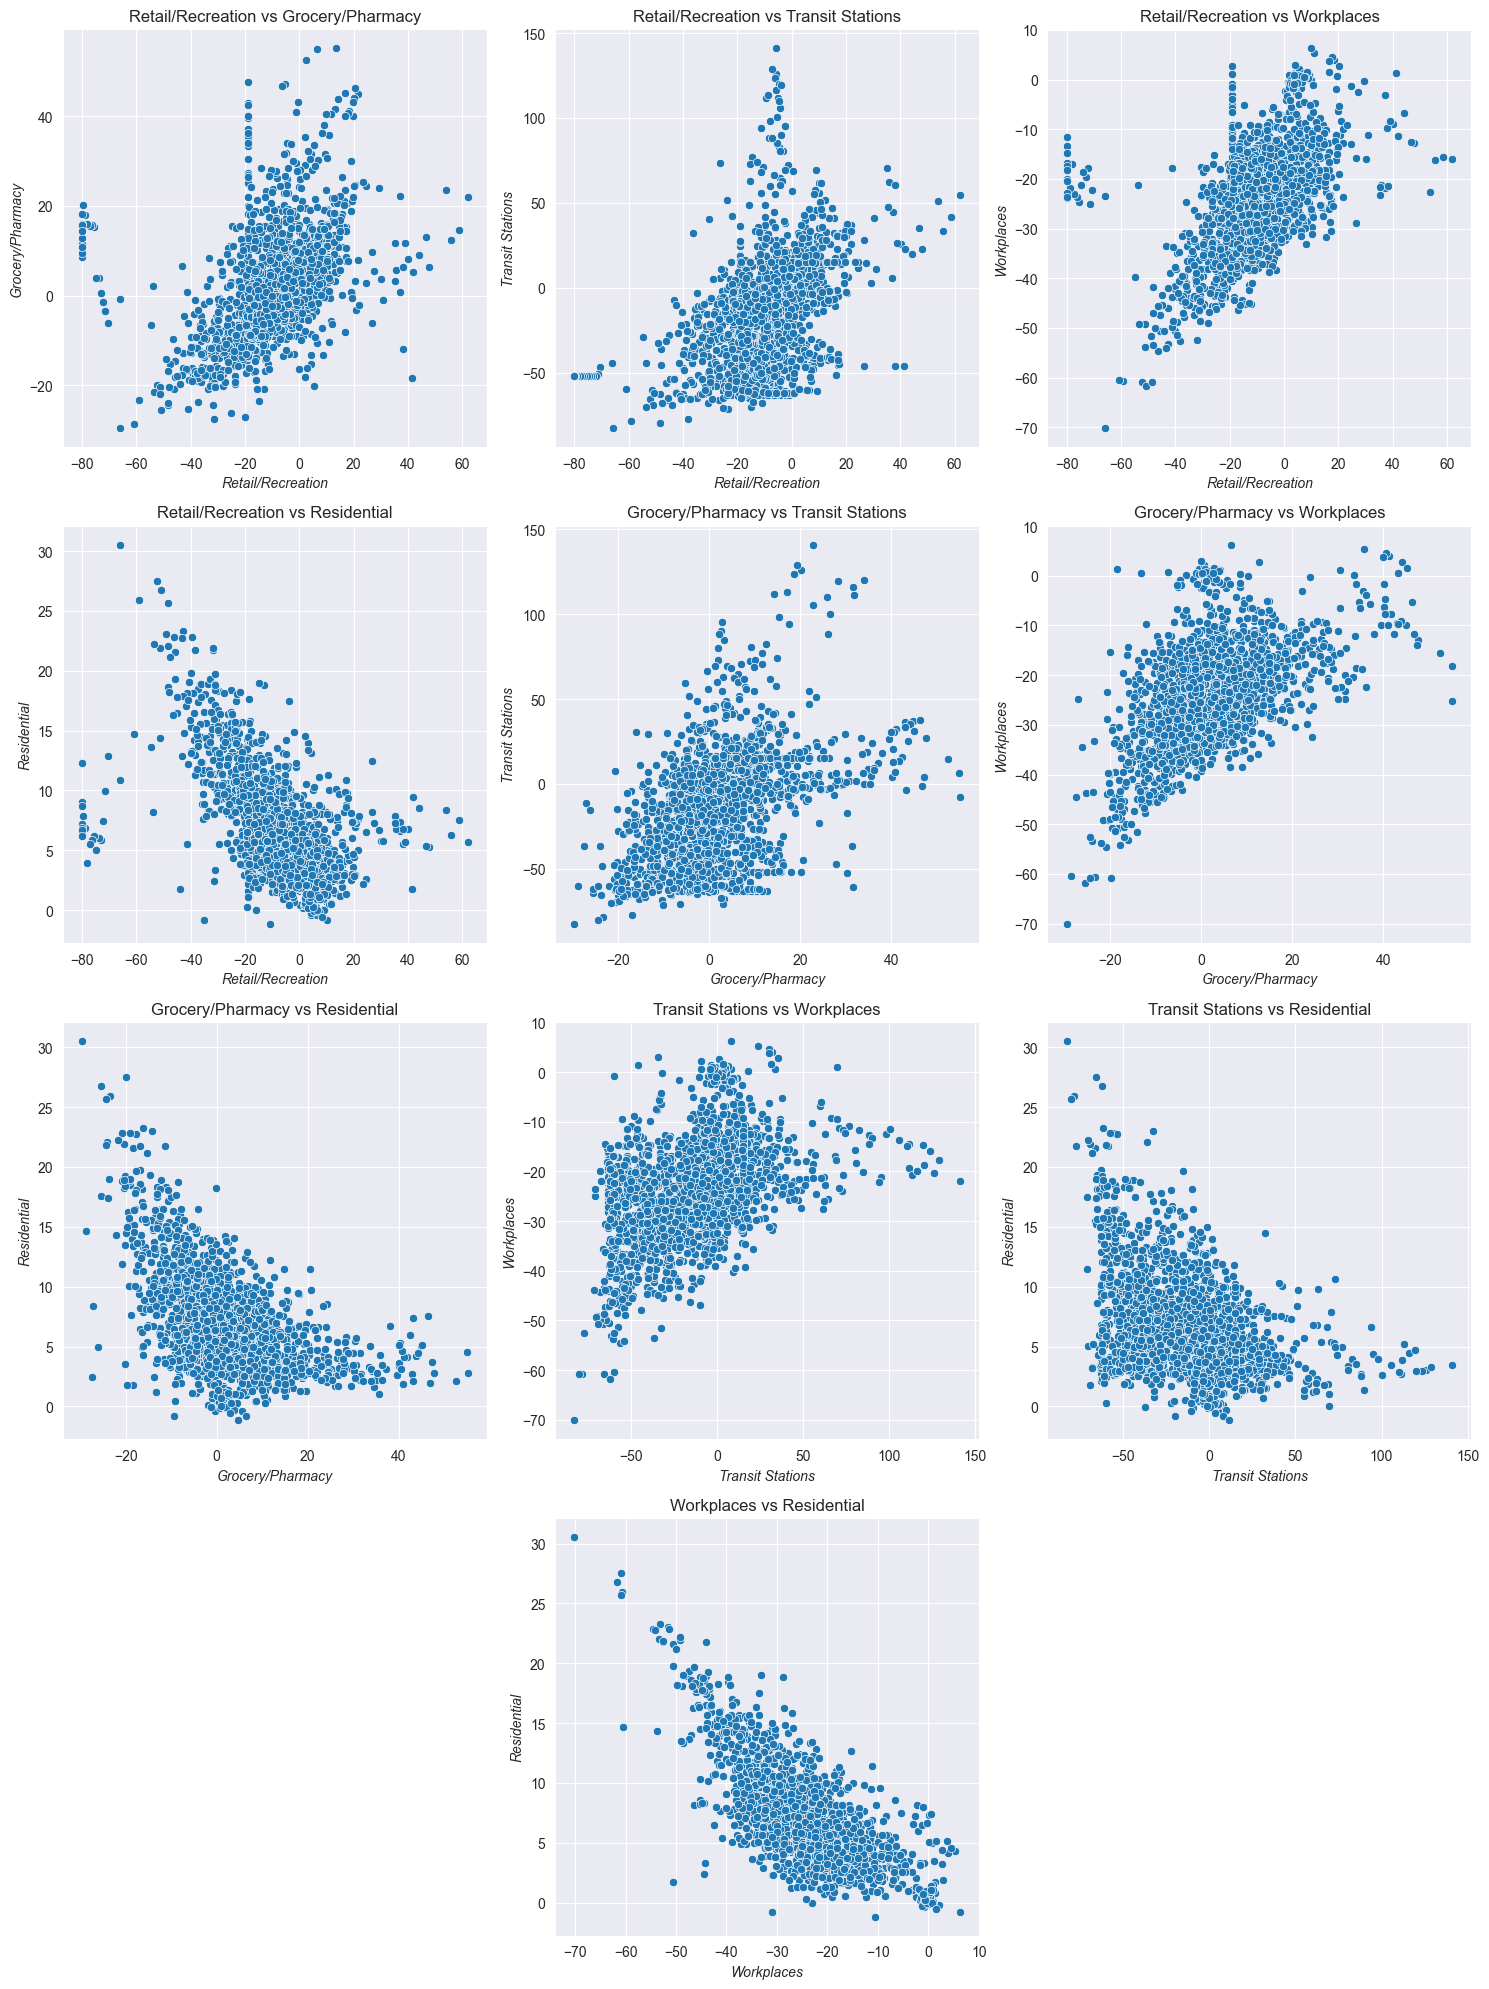

In [16]:
# linearity: scatterplots
import itertools

pairs = list(itertools.combinations(mobility_feats_short, 2))

sns.set_style("darkgrid")
fig, axes = plt.subplots(4, 3, figsize=(15, 20))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=monthly, x=x, y=y, ax=ax)
    ax.set_xlabel(x, style='italic')
    ax.set_ylabel(y, style='italic')
    ax.set_title(f"{x} vs {y}")

x_last, y_last = pairs[-1]

sns.scatterplot(data=monthly, x=x_last, y=y_last, ax=axes[10])
axes[10].set_title(f"{x_last} vs {y_last}")
axes[10].set_xlabel(x_last, style='italic')
axes[10].set_ylabel(y_last, style='italic')

# hide unused axes: 9 and 11
axes[9].set_visible(False)
axes[11].set_visible(False)

plt.tight_layout()
plt.show()



/Users/rorygardner/Documents/GitHub/cyber_squadron/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/rorygardner/Documents/GitHub/cyber_squadron/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


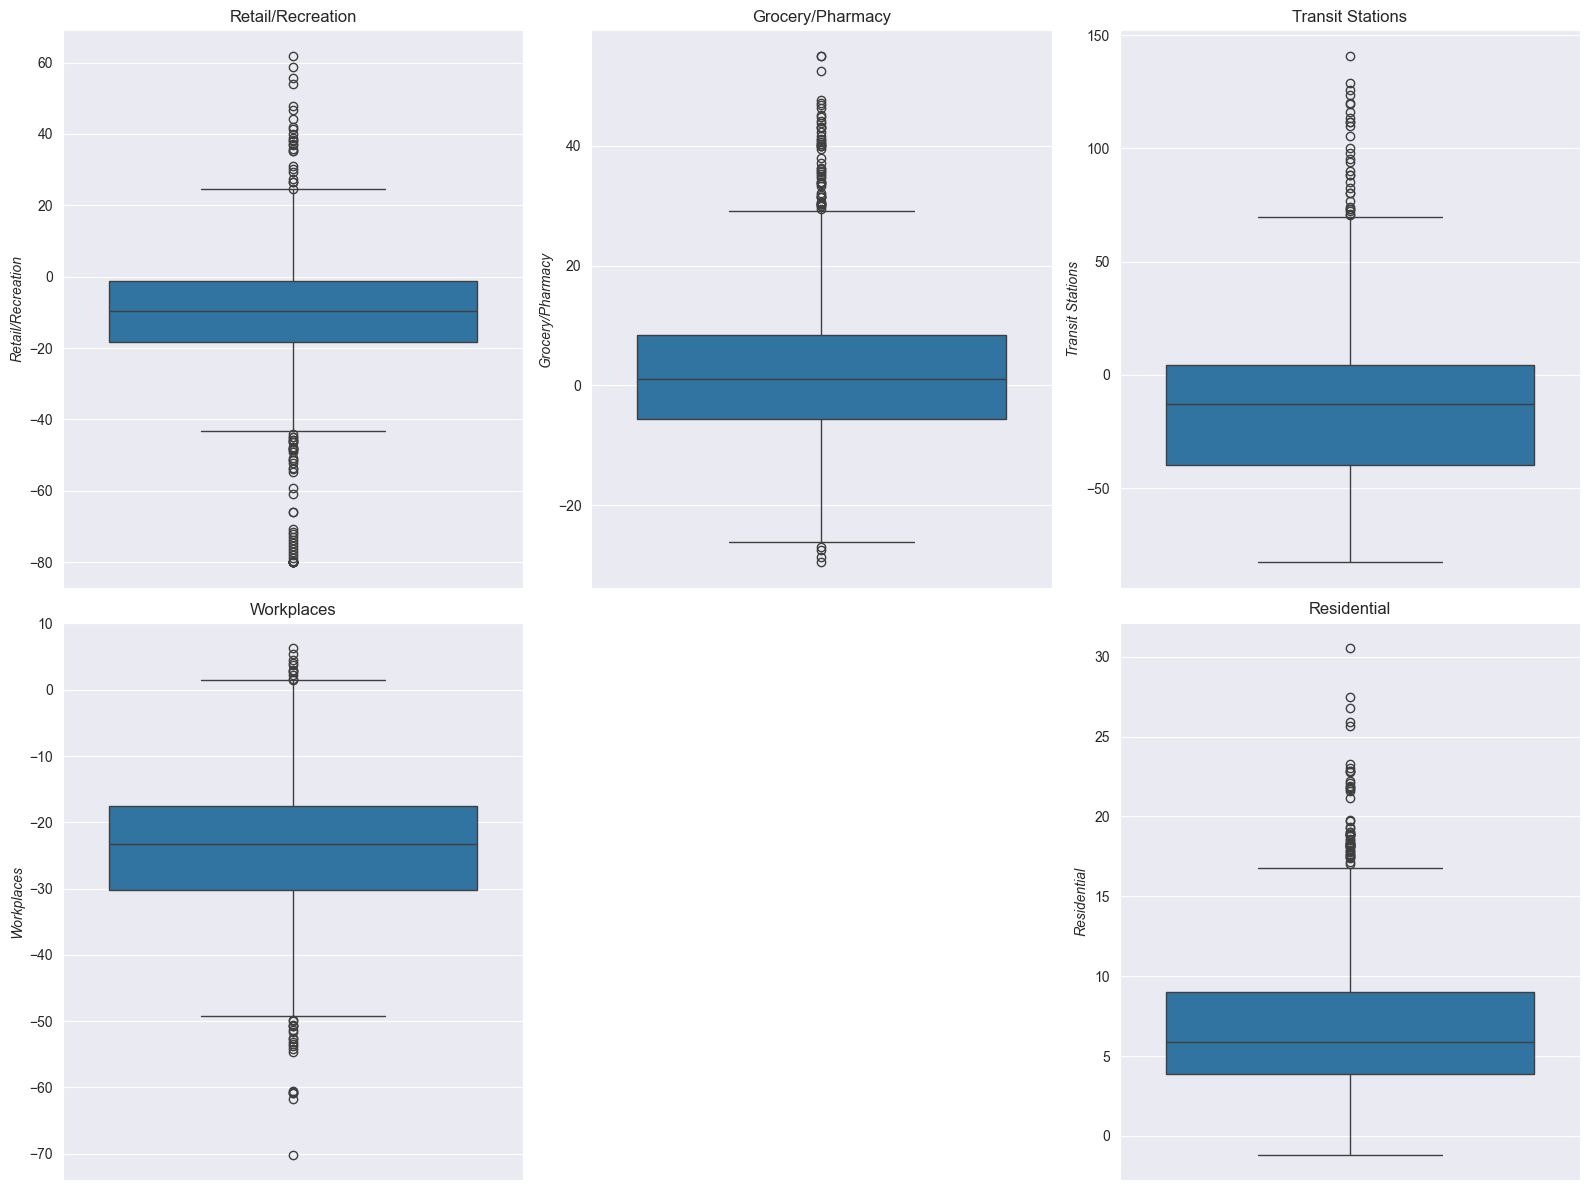

In [25]:
# outliers

sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

axes = axes.flatten()

for ax, var in zip(axes, mobility_feats_short): 
    sns.boxplot(data=monthly, y=var, ax=ax)
    ax.set_ylabel(var, style='italic')
    ax.set_title(var)

var_last = mobility_feats_short[-1]
log_res = np.log10(monthly["Residential"])
inv_res = 1/monthly['Residential']
sqr_res = monthly['Residential']**2
sqrt_res = monthly['Residential']**0.5 # best transformation

sns.boxplot(data=monthly, y=var_last, ax=axes[5])
axes[5].set_ylabel(var_last, style='italic')
axes[5].set_title(var)

# hide unused axes
axes[4].set_visible(False)

plt.tight_layout()
plt.show()

/Users/rorygardner/Documents/GitHub/cyber_squadron/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/rorygardner/Documents/GitHub/cyber_squadron/venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


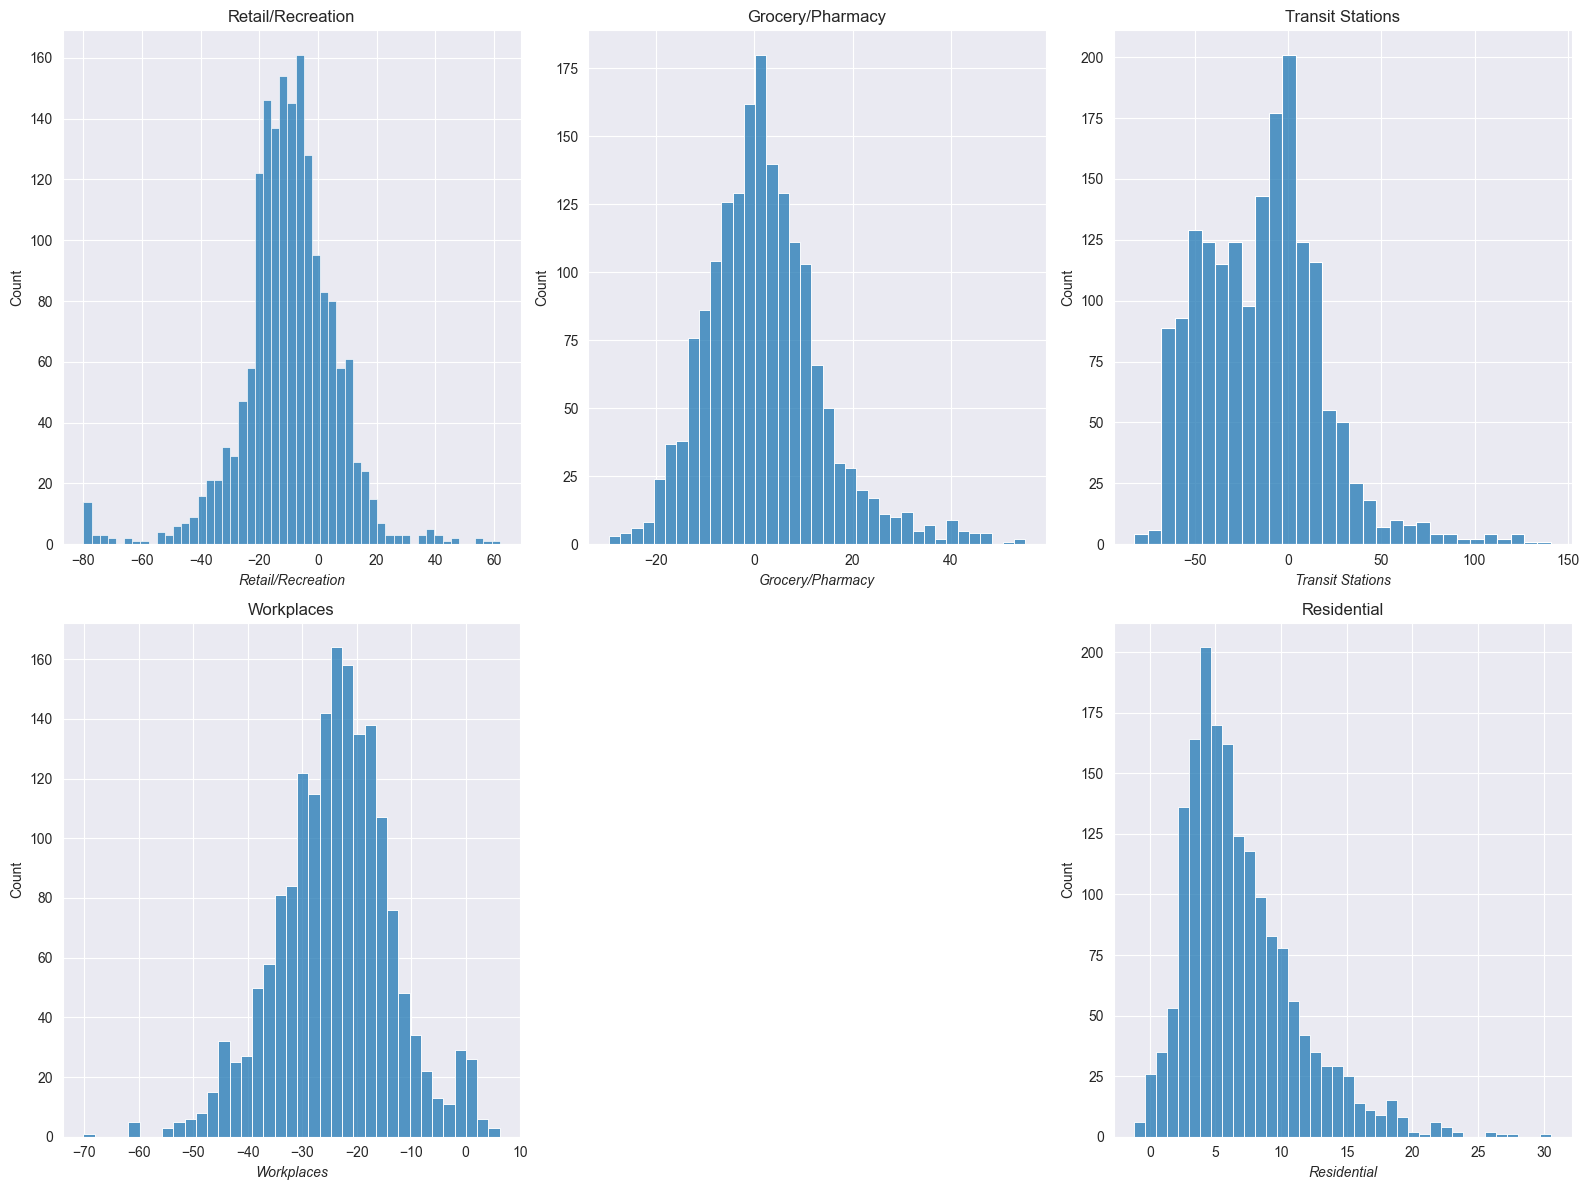

In [26]:
# outliers

sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

axes = axes.flatten()

for ax, var in zip(axes, mobility_feats_short): 
    sns.histplot(data=monthly, x=var, ax=ax)
    ax.set_xlabel(var, style='italic')
    ax.set_title(var)

var_last = mobility_feats_short[-1]
log_res = np.log10(monthly["Residential"])
inv_res = 1/monthly['Residential']
sqr_res = monthly['Residential']**2
sqrt_res = monthly['Residential']**0.5 # best transformation

sns.histplot(data=monthly, x=var_last, ax=axes[5])
axes[5].set_xlabel(var_last, style='italic')
axes[5].set_title(var)

# hide unused axes
axes[4].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
# outlier flagging: 

b_rr = 1/np.quantile(monthly['Retail/Recreation'], 0.75)
b_gp = 1/np.quantile(monthly['Grocery/Pharmacy'], 0.75)
b_t = 1/np.quantile(monthly['Transit Stations'], 0.75)
b_w = 1/np.quantile(monthly['Workplaces'], 0.75)
b_res = 1/np.quantile(monthly['Residential'], 0.75)

rr_mad = np.median(abs(monthly['Retail/Recreation']-np.median(monthly['Retail/Recreation'])))
gp_mad = np.median(abs(monthly['Grocery/Pharmacy']-np.median(monthly['Grocery/Pharmacy'])))
t_mad = np.median(abs(monthly['Transit Stations']-np.median(monthly['Transit Stations'])))
w_mad = np.median(abs(monthly['Workplaces']-np.median(monthly['Workplaces'])))
res_mad = np.median(abs(monthly['Residential']-np.median(monthly['Residential'])))

# mad/modified z-score 
monthly['rr_mad_outlier'] = (b_rr*(monthly['Retail/Recreation']-np.median(monthly['Retail/Recreation'])/rr_mad)) > 3.5
monthly['gp_mad_outlier'] = (b_gp*(monthly['Grocery/Pharmacy']-np.median(monthly['Grocery/Pharmacy'])/gp_mad)) > 3.5
monthly['t_mad_outlier'] = (b_t*(monthly['Transit Stations']-np.median(monthly['Transit Stations'])/t_mad)) > 3.5
monthly['w_mad_outlier'] = (b_w*(monthly['Workplaces']-np.median(monthly['Workplaces'])/w_mad)) > 3.5
monthly['res_mad_outlier'] = (b_res*(monthly['Residential']-np.median(monthly['Residential'])/res_mad)) > 3.5

for mad in ['rr_mad_outlier', 'gp_mad_outlier', 't_mad_outlier', 'w_mad_outlier', 'res_mad_outlier']: 
    print(f"\n{mad}: {np.sum(monthly[mad])}")

print(f"\n\n0.5% of data: {monthly.size*0.005:.2f}")

for feat in mobility_feats_short: 
    perc_low = np.percentile(monthly[feat], 0.005)
    perc_up = np.percentile(monthly[feat], 0.995)
    out = ((monthly[feat] < perc_low) | (monthly[feat] > perc_up)).sum()
    print(f"\n{feat}: {out}, {out/monthly.size*100:.2f}%")




rr_mad_outlier: 1142

gp_mad_outlier: 52

t_mad_outlier: 269

w_mad_outlier: 1

res_mad_outlier: 0


0.5% of data: 139.92

Retail/Recreation: 1731, 6.19%

Grocery/Pharmacy: 1731, 6.19%

Transit Stations: 1732, 6.19%

Workplaces: 1732, 6.19%

Residential: 1732, 6.19%
